# Technical Space Competitors
- Specifically, for Neok001 -> what patents could create blocking or design-around pressure  

But even in claims, you may see stealth and strategic drafting 
- For example, instead of using the explict naming of the target, they may use sequence identifications or structure-based claims
- To address both false negatives (strategic drafting) and false positives, independent claim text was analyzed using an AI-assisted classification pipeline
- The claims of each patent was extracted and submitted to an API-based AI model for labeling

**The model is used to detect and classify claims that involve:**
- Bispecific ADC constructs
- Antibodies targeting B7-H3
- Antibodies targeting ROR1 
- TOP1 payloads

_Under the working assumption that all records represent ADC and oncology-related inventions, due to prior CPC-based filtering performed in The Lens_

### **Scope Limitation**:
As mentioned previously in "03_direct_us_atents.ipynb", this analysis is restricted to the textual claim content
- Images (Drawings, chemical structure, etc) will not be examined
- Structure-image parsing is beyond the scope of the project

<br>

---

## Prompts for detecting same technical space

In [ ]:
#Provide the developer prompt
instructions = """
You are a pharmaceutical patent analyst evaluating competitive risk to an ADC program targeting ROR1 or B7-H3 with a topoisomerase I inhibitor payload.

Core rules:
- Analyze CLAIMS first. Title and abstract are secondary.
- Base conclusions on claimed scope, not background discussion.
- Be conservative and evidence-based.
- Only assign medium/high confidence if claims clearly support it.
- Avoid over-inference from generic oncology language.

Return strict JSON only.
Keep reasoning concise but specific (3–4 sentences per section).
"""

In [ ]:
prompt = """
Analyze the following patent to determine if it poses competitive risk to an ADC program targeting:
- ROR1
- B7-H3
- A topoisomerase I inhibitor payload

TITLE:
{title}

ABSTRACT:
{abstract}

CLAIMS:
{claims}

==============================
STEP 1: Evaluate ROR1 targeting
==============================

HIGH confidence:
- Explicit mention of "ROR1", "NTRKR1", or full receptor name.
- Antibody claims specifying ROR1 binding.

MEDIUM confidence:
- Claims describing an orphan receptor tyrosine kinase with:
    • Wnt5a non-canonical signaling involvement
    • Expression in CLL or mantle cell lymphoma
    • Restricted normal adult expression
    • Binding to cysteine-rich or kringle domains
- Sequence-defined antibody clearly tied to that receptor.

LOW confidence:
- Sequence-defined antibody without clear antigen disclosure.

Do NOT flag:
- Generic tyrosine kinase
- Generic orphan receptor
- Generic B-cell antigen

==============================
STEP 2: Evaluate B7-H3 targeting
==============================

HIGH confidence:
- Explicit "B7-H3" or "CD276"
- Antibody claims specifying B7-H3 binding

MEDIUM confidence:
- Target described as 4Ig (IgV-IgC-IgV-IgC) B7 family member
- Overexpressed in neuroblastoma AND prostate AND lung/breast
- B7 family member explicitly NOT PD-L1, PD-L2, B7-H4, CTLA-4

LOW confidence:
- Sequence-defined antibody without antigen clarity

Do NOT flag:
- Generic immune checkpoint
- Generic B7 family language alone

CRITICAL DISAMBIGUATION - B7-H3 vs B7-H4:
- B7-H3 = CD276 → pro-tumorigenic, overexpressed in solid tumors, therapeutic target
- B7-H4 = VTCN1 = B7S1 → completely different protein and gene, do NOT flag as B7-H3
- If patent explicitly mentions B7-H4, VTCN1, or B7S1 → set b7h3_flag = false
- These are frequently confused — verify the exact target before flagging

==============================
STEP 3: Evaluate Topoisomerase I payload
==============================

HIGH confidence:
- Explicit DXd, SN-38, exatecan, irinotecan, topotecan, camptothecin, belotecan
- Explicit "topoisomerase I inhibitor" in payload claim

MEDIUM confidence:
- "Camptothecin derivative" or analog
- Payload described as causing DNA single-strand breaks via topo I trapping
- Structural description of camptothecin-like lactone scaffold

Do NOT flag:
- Generic DNA damage
- Generic cytotoxic payload
- Generic topoisomerase inhibitor (must specify Type I)

==============================
STEP 4: Evaluate Bispecific Constructs
==============================

bispecific_flag = true ONLY if:
- Claims describe a bispecific/multispecific antibody
AND
- One arm meets ROR1 or B7-H3 criteria above

==============================
STEP 5: Determine competitor_flag
==============================

Set competitor_flag = true ONLY if:
- ror1_flag is true with medium or high confidence
OR
- b7h3_flag is true with medium or high confidence
OR
- topo1_flag is true with medium or high confidence
OR
- bispecific_flag is true AND ROR1/B7-H3 confidence ≥ medium

If confidence is LOW only → competitor_flag = false
But note manual review in reasoning.

==============================
Return STRICT JSON:
==============================

{{
  "ror1_flag": true/false,
  "ror1_confidence": "high/medium/low/none",
  "ror1_reasoning": "",
  "b7h3_flag": true/false,
  "b7h3_confidence": "high/medium/low/none",
  "b7h3_reasoning": "",
  "topo1_flag": true/false,
  "topo1_confidence": "high/medium/low/none",
  "topo1_reasoning": "",
  "bispecific_flag": true/false,
  "bispecific_reasoning": "",
  "competitor_flag": true/false,
  "competitor_reasoning": ""
}}
"""

In [ ]:
def competitor_patent(row):
    filled_prompt = prompt.format(
        title=row['title'],
        abstract=row['abstract_text'],
        claims=row['claims_text']
    )
    
    response = client.chat.completions.create(
        model="gpt-4o", #Using 4o here for better reasoning on complex patent claims. Will be using composiiton patent subset later to reduce token usage and cost
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": filled_prompt}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    
    return json.loads(response.choices[0].message.content)

## API Validation Using a Manually Curated Patent Set

Again, ran it on ABL Bio Patent profile and noticed B7-H4 was flagged as B7-H3. So added "CRITICAL DISAMBIGUATION" paragraph to user prompt
- Results of this is in `abl_patents_competitor_4o_mini_v3.csv`

## AI-assisted flagging on 1064 Composition Patents

In [ ]:
import pandas as pd

ai_input = pd.read_csv("patents_classified_v3mini.csv") #the results with composition labeling
patents_for_ai = pd.read_csv("patents_for_ai.csv") #what was inputted, which has title, abstract and claims text

In [ ]:
composition_ids = ai_input.loc[
    ai_input["patent_type"] == "Composition",
    "lens_id"
]

In [ ]:
composition_text = patents_for_ai[
    patents_for_ai["lens_id"].isin(composition_ids)
].copy()

In [ ]:
results = []
for idx, row in composition_text.iterrows():
    print(f"Processing {idx+1}/{len(composition_text)}: {row['lens_id']}")
    try:
        result = competitor_patent(row)
        result['lens_id'] = row['lens_id']
        results.append(result)
    except Exception as e:
        print(f"  Error: {e}")
        results.append({'lens_id': row['lens_id'], 'error': str(e)})

results_df = pd.DataFrame(results)
results_df.to_csv("patents_competitor_4o.csv", index=False)
print("Done!")
results_df.head()

In [ ]:
#Couple lines ran in limit of 30K TPM for gpt-4o 
error_ids = results_df[results_df['error'].notna()]['lens_id'].tolist()
error_df = composition_text[composition_text['lens_id'].isin(error_ids)]
print(f"Errors to rerun: {len(error_df)}")

#Errors to rerun: 16

In [ ]:
#Will truncate the claims for those 16 patents, to stay within token limits
def competitor_patent(row):
    claims = str(row['claims_text'])[:6000]  # truncate here
    filled_prompt = prompt.format(
        title=row['title'],
        abstract=row['abstract_text'],
        claims=claims  # use truncated version
    )
    
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": filled_prompt}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    
    return json.loads(response.choices[0].message.content)

In [ ]:
rerun_results = []
for idx, row in error_df.iterrows():
    print(f"Processing {row['lens_id']}")
    try:
        result = competitor_patent(row)
        result['lens_id'] = row['lens_id']
        rerun_results.append(result)
    except Exception as e:
        print(f"  Error: {e}")
        rerun_results.append({'lens_id': row['lens_id'], 'error': str(e)})
    
    
# combine with clean results
clean_df = results_df[results_df['error'].isna()]
rerun_df = pd.DataFrame(rerun_results)
final_df = pd.concat([clean_df, rerun_df], ignore_index=True)
final_df.to_csv("patents_targets_full.csv", index=False)
print(f"Total: {len(final_df)}")

After saving the `patents_targets_full.csv` in the course repo, uploaded onto this repo in `/data/ai_results/patents_targets_full.csv`
- The remaining code can now be run on this notebook

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

competitor_df = pd.read_csv("../data/ai_results/patents_targets_full.csv")

# quick summary of flags
print(competitor_df['ror1_confidence'].value_counts())
print(competitor_df['b7h3_confidence'].value_counts())
print(competitor_df['topo1_confidence'].value_counts())
print(f"\nTotal competitors: {df['competitor_flag'].sum()}")

ror1_confidence
none      1029
high        27
medium       1
Name: count, dtype: int64
b7h3_confidence
none      997
high       58
medium      2
Name: count, dtype: int64
topo1_confidence
none      910
high      111
medium     23
low        13
Name: count, dtype: int64

Total competitors: 188


In [37]:
print(f"ROR1 high/medium: {competitor_df['ror1_confidence'].isin(['high','medium']).sum()}")   # 28
print(f"B7-H3 high/medium: {competitor_df['b7h3_confidence'].isin(['high','medium']).sum()}")  # 60
print(f"Topo1 high/medium: {competitor_df['topo1_confidence'].isin(['high','medium']).sum()}") # 134

# unique patents hitting at least one
competitor_ids = set(
    competitor_df[competitor_df['ror1_confidence'].isin(['high','medium'])]['lens_id'].tolist() +
    competitor_df[competitor_df['b7h3_confidence'].isin(['high','medium'])]['lens_id'].tolist() +
    competitor_df[competitor_df['topo1_confidence'].isin(['high','medium'])]['lens_id'].tolist()
)
print(f"Unique competitor patents: {len(competitor_ids)}")

ROR1 high/medium: 28
B7-H3 high/medium: 60
Topo1 high/medium: 134
Unique competitor patents: 188


In [38]:
# see how many hit multiple targets (as total competitors is 187 but total high is higher)
competitor_df['targets_hit'] = (
    competitor_df['ror1_confidence'].isin(['high', 'medium']).astype(int) +
    competitor_df['b7h3_confidence'].isin(['high', 'medium']).astype(int) +
    competitor_df['topo1_confidence'].isin(['high', 'medium']).astype(int)
)

print(competitor_df['targets_hit'].value_counts().sort_index())

targets_hit
0    869
1    158
2     26
3      4
Name: count, dtype: int64


In [39]:
# patents where model said not competitor but we'd flag them
competitor_df[
    (competitor_df['competitor_flag'] == False) & 
    (competitor_df['targets_hit'] >= 1)
][['lens_id', 'ror1_confidence', 'b7h3_confidence', 'topo1_confidence', 'competitor_flag', 'competitor_reasoning']]

,lens_id,ror1_confidence,b7h3_confidence,topo1_confidence,competitor_flag,competitor_reasoning
244,179-698-917-483-710,medium,none,none,False,While ROR1 is mentioned as a potential kinase ...


In [40]:
#Set the one above as competitor flag, as it meets the criteria of hitting at least one target with medium or high confidence
competitor_df['competitor_flag'] = competitor_df['lens_id'].isin(competitor_ids)
print(f"Total competitors: {competitor_df['competitor_flag'].sum()}")  # 188

Total competitors: 188


In [44]:
#combine it with our full patent dataset to see details on the competitors
import pandas as pd

# classification results if needed
classified_df = pd.read_csv("../data/ai_results/patents_classified_v3mini.csv")

In [ ]:
#Initial file jsonl with all info on US jurisdiction
df_raw = pd.read_json("../data/raw/US-enforced-patents.jsonl", lines=True)
print(df_raw.shape)
print(df_raw.columns.tolist())

(2331, 16)
['lens_id', 'jurisdiction', 'doc_number', 'kind', 'date_published', 'doc_key', 'docdb_id', 'lang', 'biblio', 'families', 'sequence_listing', 'legal_status', 'abstract', 'claims', 'description', 'publication_type']


In [53]:
df_full = competitor_df.merge(df_raw[['lens_id', 'biblio']], on='lens_id', how='left')
print(df_full.shape)  # should be 1057

# extract all owners
def extract_all_owners(biblio):
    try:
        owners = biblio['parties']['owners_all']
        return [o['extracted_name']['value'] for o in owners]
    except:
        try:
            applicants = biblio['parties']['applicants']
            return [a['extracted_name']['value'] for a in applicants]
        except:
            return []

df_full['owners'] = df_full['biblio'].apply(extract_all_owners)

# explode so each owner gets its own row
df_exploded = df_full.explode('owners')

# competitor patents per owner
competitor_owners = df_exploded[df_exploded['competitor_flag'] == True]
competitor_owners['owners'].value_counts().head(40)

(1057, 17)


owners
DAIICHI SANKYO COMPANY LIMITED                                                                          11
SHANGHAI HENGRUI PHARMACEUTICAL CO. LTD                                                                  7
JIANGSU HENGRUI MEDICINE CO. LTD                                                                         6
NOVARTIS AG                                                                                              4
SYSTIMMUNE INC                                                                                           4
BIO-THERA SOLUTIONS LTD                                                                                  4
BAILI-BIO (CHENGDU) PHARMACEUTICAL CO. LTD                                                               4
JIANGSU HANSOH PHARMACEUTICAL GROUP CO. LTD                                                              3
ZYMEWORKS BC INC                                                                                         3
NOVARTIS INSTITUTES FOR BIOMED

In [49]:
counts = competitor_owners['owners'].value_counts()
print(f"Total rows in value_counts: {counts.sum()}")
print(f"Unique owners: {len(counts)}")
print(f"Competitor patents (before explode): {competitor_df['competitor_flag'].sum()}")

Total rows in value_counts: 272
Unique owners: 206
Competitor patents (before explode): 188


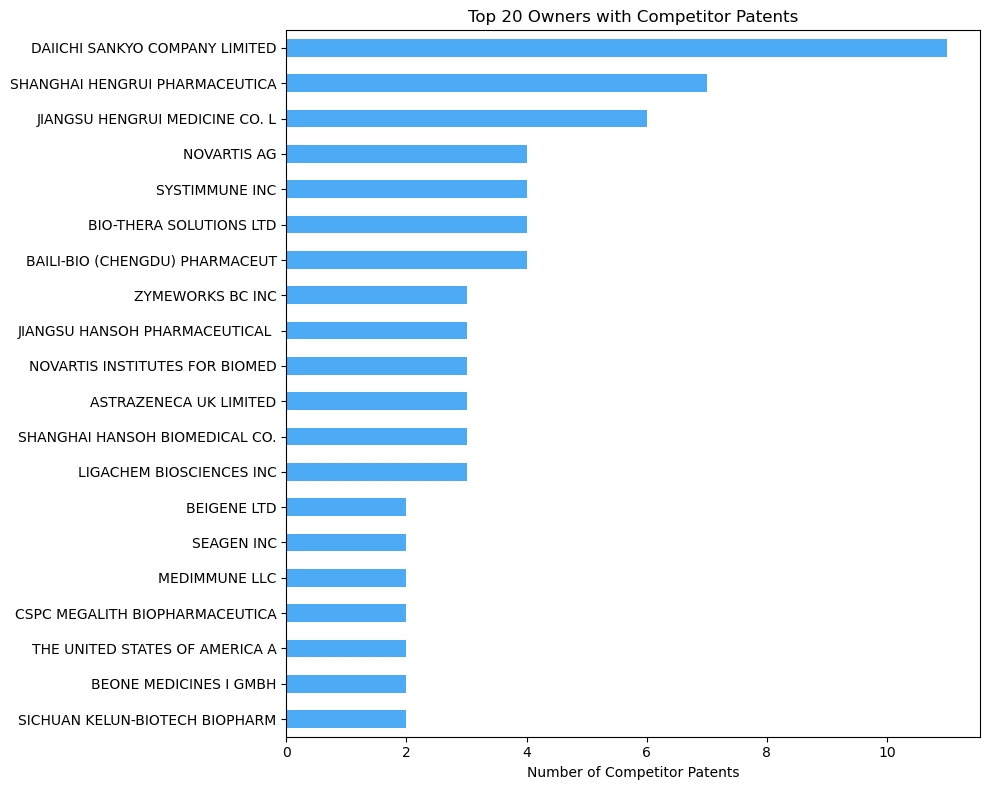

In [60]:
fig, ax = plt.subplots(figsize=(10, 8))

top20 = counts.head(20).sort_values()
top20.index = [name[:30] for name in top20.index]  # truncate to 30 chars

top20.plot(kind='barh', ax=ax, color='#2196F3', alpha=0.8)
ax.set_title('Top 20 Owners with Competitor Patents')
ax.set_xlabel('Number of Competitor Patents')
ax.set_ylabel('')
plt.tight_layout()
#to save: plt.savefig("competitor_owners.png", dpi=150)
plt.show()

In [54]:
# check if ABL Bio appears anywhere in the full dataset
df_exploded[df_exploded['owners'].str.contains('ABL', na=False)]['owners'].value_counts()

owners
ABL BIO INC    2
ABLYNX N.V     1
Name: count, dtype: int64

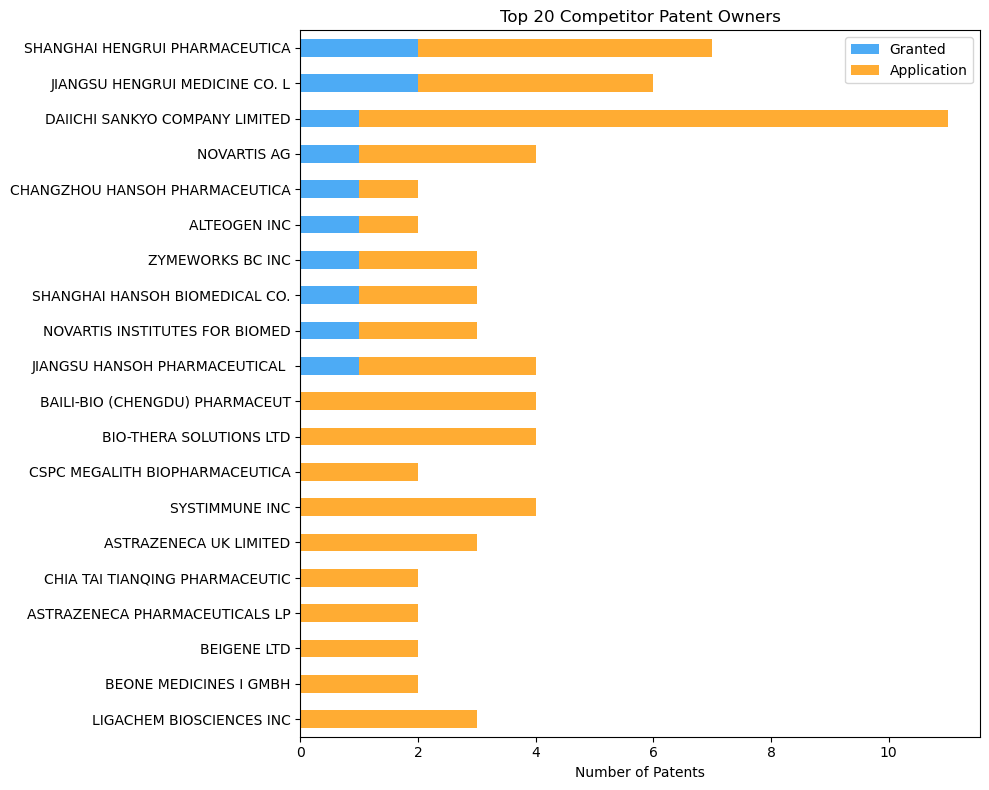

In [59]:
df_exploded2 = df_full.copy()
df_exploded2 = df_exploded2.merge(df_raw[['lens_id', 'publication_type']], on='lens_id', how='left')
df_exploded2 = df_exploded2.explode('owners')
df_exploded2['owners_short'] = df_exploded2['owners'].str[:30]

# filter competitors only
comp = df_exploded2[df_exploded2['competitor_flag'] == True]

# pivot for stacked bar
pivot = comp.groupby(['owners_short', 'publication_type']).size().unstack(fill_value=0)

# get top 20 by total
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.nlargest(20, 'total').drop(columns='total').sort_values(pivot.columns[0])

# plot
fig, ax = plt.subplots(figsize=(10, 8))
pivot.plot(kind='barh', stacked=True, ax=ax, 
           color={'GRANTED_PATENT': '#2196F3', 'PATENT_APPLICATION': '#FF9800'}, 
           alpha=0.8)
ax.set_title('Top 20 Competitor Patent Owners')
ax.set_xlabel('Number of Patents')
ax.set_ylabel('')
ax.legend(['Granted', 'Application'])
plt.tight_layout()
#to save: plt.savefig("competitor_owners_status.png", dpi=150)
plt.show()